In [1]:
import pandas as pd

In [2]:
train_df = pd.read_csv('../results/outputs/Selected/train_top10_features.csv')
test_df = pd.read_csv('../results/outputs/Selected/test_top10_features.csv')

In [3]:
train_df_pca = pd.read_csv('../results/outputs/PCA/pca_train.csv')
test_df_pca = pd.read_csv('../results/outputs/PCA/pca_test.csv')

In [4]:
print(test_df.shape)
print(train_df.shape)

(220, 11)
(880, 11)


In [5]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score

In [6]:
feature_cols = [c for c in train_df.columns if c != "target"]

x_train = train_df[feature_cols]
y_train = train_df["target"]

x_test = test_df[feature_cols]
y_test = test_df["target"]

In [7]:
knn = KNeighborsClassifier()
knn.fit(x_train, y_train)

knn_preds = knn.predict(x_test)
knn_accuracy = accuracy_score(y_test, knn_preds)

print("KNN Accuracy:", knn_accuracy)
print(classification_report(y_test, knn_preds))

KNN Accuracy: 0.8909090909090909
              precision    recall  f1-score   support

           0       0.90      0.88      0.89        74
           1       0.92      0.92      0.92        72
           2       0.86      0.88      0.87        74

    accuracy                           0.89       220
   macro avg       0.89      0.89      0.89       220
weighted avg       0.89      0.89      0.89       220



In [8]:
print(knn.get_params())

{'algorithm': 'auto', 'leaf_size': 30, 'metric': 'minkowski', 'metric_params': None, 'n_jobs': None, 'n_neighbors': 5, 'p': 2, 'weights': 'uniform'}


In [9]:
feature_cols_pca = [c for c in train_df_pca.columns if c != "target"]

x_train_pca = train_df_pca[feature_cols_pca]
y_train_pca = train_df_pca["target"]

x_test_pca = test_df_pca[feature_cols_pca]
y_test_pca = test_df_pca["target"]

knn_pca = KNeighborsClassifier()
knn_pca.fit(x_train_pca, y_train_pca)

knn_preds_pca = knn_pca.predict(x_test_pca)
knn_accuracy_pca = accuracy_score(y_test_pca, knn_preds_pca)

knn_preds_pca_t = knn_pca.predict(x_train_pca) 
knn_accuracy_pca_train = accuracy_score(y_train_pca, knn_preds_pca_t)

print("KNN PCA Test Accuracy:", knn_accuracy_pca)
print("KNN PCA Training Accuracy:", knn_accuracy_pca_train)
print(classification_report(y_test_pca, knn_preds_pca))

KNN PCA Test Accuracy: 0.8727272727272727
KNN PCA Training Accuracy: 0.9159090909090909
              precision    recall  f1-score   support

           0       0.88      0.85      0.86        74
           1       0.87      0.90      0.88        72
           2       0.88      0.86      0.87        74

    accuracy                           0.87       220
   macro avg       0.87      0.87      0.87       220
weighted avg       0.87      0.87      0.87       220



In [10]:
#No overfitting or underfitting goin on

In [ ]:
#PCA data dosent show increase in accuracy and accuracy is lower so continue with the selected features data

In [12]:
#Hyperparameter tuning KNN

In [13]:
from sklearn.model_selection import GridSearchCV

In [14]:
knn_param_grid = {
    'n_neighbors': [3,5,7,9,11,13,15,17,19,21],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski', 'hamming']
}

In [15]:
grid_knn = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=knn_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_knn.fit(x_train, y_train)

print("Best KNN parameters:", grid_knn.best_params_)
print("Best KNN CV accuracy:", grid_knn.best_score_)

Fitting 5 folds for each of 80 candidates, totalling 400 fits


Best KNN parameters: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}
Best KNN CV accuracy: 0.8886363636363637


In [16]:
best_knn = grid_knn.best_estimator_
tuned_knn_preds = best_knn.predict(x_test)
tuned_knn_accuracy = accuracy_score(y_test, tuned_knn_preds)

print("Tuned KNN Test Accuracy for Test Data:", tuned_knn_accuracy)
print(classification_report(y_test, tuned_knn_preds))

tuned_knn_preds_t = best_knn.predict(x_train)
tuned_knn_accuracy_t = accuracy_score(y_train, tuned_knn_preds_t)

print("Tuned KNN train Accuracy for Training Data:", tuned_knn_accuracy_t)
print(classification_report(y_train, tuned_knn_preds_t))

Tuned KNN Test Accuracy for Test Data: 0.8909090909090909
              precision    recall  f1-score   support

           0       0.94      0.82      0.88        74
           1       0.86      0.94      0.90        72
           2       0.88      0.91      0.89        74

    accuracy                           0.89       220
   macro avg       0.89      0.89      0.89       220
weighted avg       0.89      0.89      0.89       220

Tuned KNN train Accuracy for Training Data: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       299
           1       1.00      1.00      1.00       286
           2       1.00      1.00      1.00       295

    accuracy                           1.00       880
   macro avg       1.00      1.00      1.00       880
weighted avg       1.00      1.00      1.00       880



In [ ]:
#So the traned model has a risk of overfitting with training accuracy being 100%
#TO futher understand whats going on check the selected parameters by gridsearchv

In [28]:
print(best_knn.get_params())

{'algorithm': 'auto', 'leaf_size': 30, 'metric': 'manhattan', 'metric_params': None, 'n_jobs': None, 'n_neighbors': 3, 'p': 2, 'weights': 'distance'}


In [ ]:
#Also gonna check hyperparameter tuning with f1-macro as scoring metric to see if it differ the results

In [31]:
grid_knn = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=knn_param_grid,
    cv=5,
    scoring='f1_macro', #f1 macro
    n_jobs=-1,
    verbose=1
)

grid_knn.fit(x_train, y_train)

print("Best KNN parameters:", grid_knn.best_params_)
print("Best KNN CV accuracy:", grid_knn.best_score_)

best_knn = grid_knn.best_estimator_
tuned_knn_preds = best_knn.predict(x_test)
tuned_knn_accuracy = accuracy_score(y_test, tuned_knn_preds)

print("Tuned KNN Test Accuracy for Test Data:", tuned_knn_accuracy)
print(classification_report(y_test, tuned_knn_preds))

tuned_knn_preds_t = best_knn.predict(x_train)
tuned_knn_accuracy_t = accuracy_score(y_train, tuned_knn_preds_t)

print("Tuned KNN train Accuracy for Training Data:", tuned_knn_accuracy_t)
print(classification_report(y_train, tuned_knn_preds_t))

Fitting 5 folds for each of 60 candidates, totalling 300 fits
Best KNN parameters: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}
Best KNN CV accuracy: 0.8888546375897135
Tuned KNN Test Accuracy for Test Data: 0.8909090909090909
              precision    recall  f1-score   support

           0       0.94      0.82      0.88        74
           1       0.86      0.94      0.90        72
           2       0.88      0.91      0.89        74

    accuracy                           0.89       220
   macro avg       0.89      0.89      0.89       220
weighted avg       0.89      0.89      0.89       220

Tuned KNN train Accuracy for Training Data: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       299
           1       1.00      1.00      1.00       286
           2       1.00      1.00      1.00       295

    accuracy                           1.00       880
   macro avg       1.00      1.00      1.00       88

In [ ]:
#Both f1 macro and accuracy scoring metrics give the same results for the best parameters and accuracy scores
#So saving the model 

In [33]:
import joblib

joblib.dump(best_knn, "../results/model_trained_files/knn_model.pkl")

['../results/model_trained_files/knn_model.pkl']

In [21]:
#Visualizing

In [22]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.inspection import DecisionBoundaryDisplay

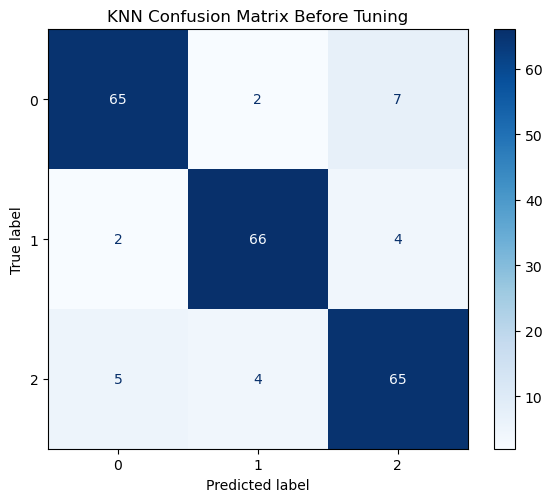

In [23]:
#Before tuning

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    knn_preds,
    cmap="Blues",
    ax=ax
)
ax.set_title("KNN Confusion Matrix Before Tuning")
plt.tight_layout()
plt.show()

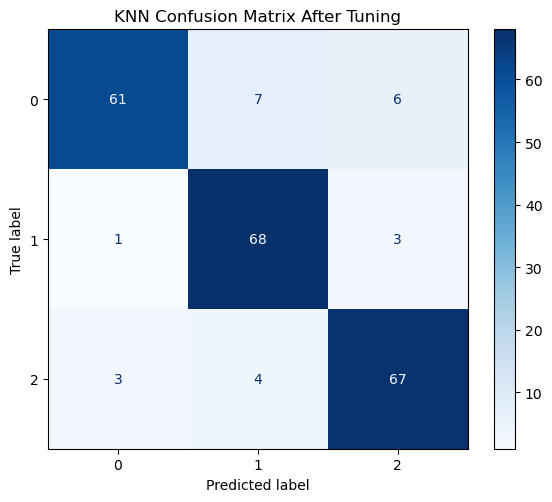

In [24]:
#After tuning

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    tuned_knn_preds,
    cmap="Blues",
    ax=ax
)
ax.set_title("KNN Confusion Matrix After Tuning")
plt.tight_layout()
plt.show()

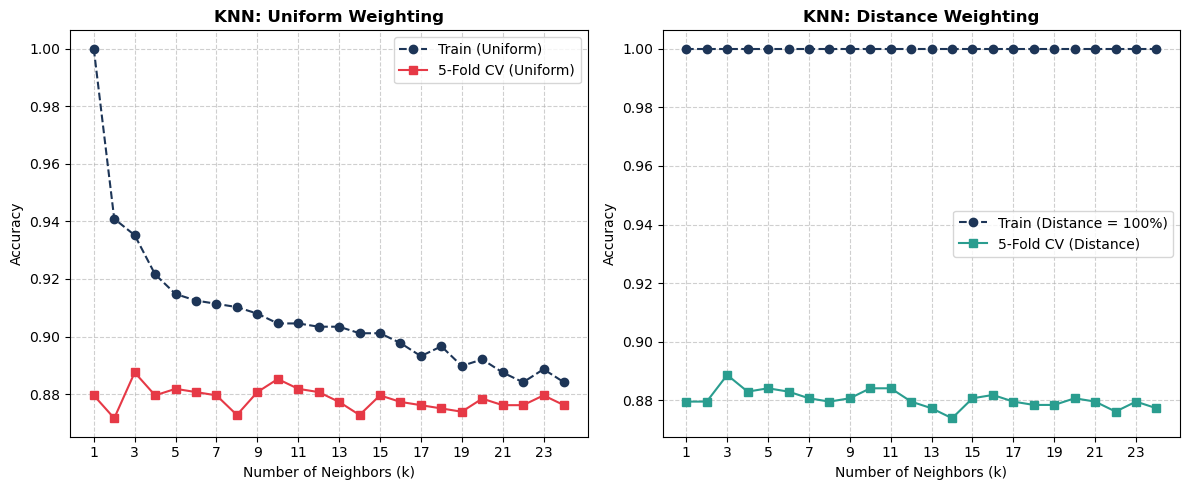

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

k_range = range(1, 25)
train_scores_uniform, cv_scores_uniform = [], []
train_scores_distance, cv_scores_distance = [], []

for k in k_range:
    # Uniform weighting
    knn_u = KNeighborsClassifier(n_neighbors=k, weights='uniform', metric='manhattan')
    knn_u.fit(x_train, y_train)
    train_scores_uniform.append(knn_u.score(x_train, y_train))
    cv_scores_uniform.append(cross_val_score(knn_u, x_train, y_train, cv=5, scoring='accuracy').mean())
    
    # Distance weighting
    knn_d = KNeighborsClassifier(n_neighbors=k, weights='distance', metric='manhattan')
    knn_d.fit(x_train, y_train)
    train_scores_distance.append(knn_d.score(x_train, y_train))
    cv_scores_distance.append(cross_val_score(knn_d, x_train, y_train, cv=5, scoring='accuracy').mean())

plt.figure(figsize=(12, 5))

# Uniform plot
plt.subplot(1, 2, 1)
plt.plot(k_range, train_scores_uniform, 'o--', color='#1d3557', label='Train (Uniform)')
plt.plot(k_range, cv_scores_uniform, 's-', color='#e63946', label='5-Fold CV (Uniform)')
plt.title('KNN: Uniform Weighting', fontweight='bold')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.xticks(range(1, 25, 2))
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Distance plot
plt.subplot(1, 2, 2)
plt.plot(k_range, train_scores_distance, 'o--', color='#1d3557', label='Train (Distance = 100%)')
plt.plot(k_range, cv_scores_distance, 's-', color='#2a9d8f', label='5-Fold CV (Distance)')
plt.title('KNN: Distance Weighting', fontweight='bold')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.xticks(range(1, 25, 2))
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.savefig('../results/eda_visualizations/knn_k_tuning_tradeoff.png', dpi=200)
plt.show()

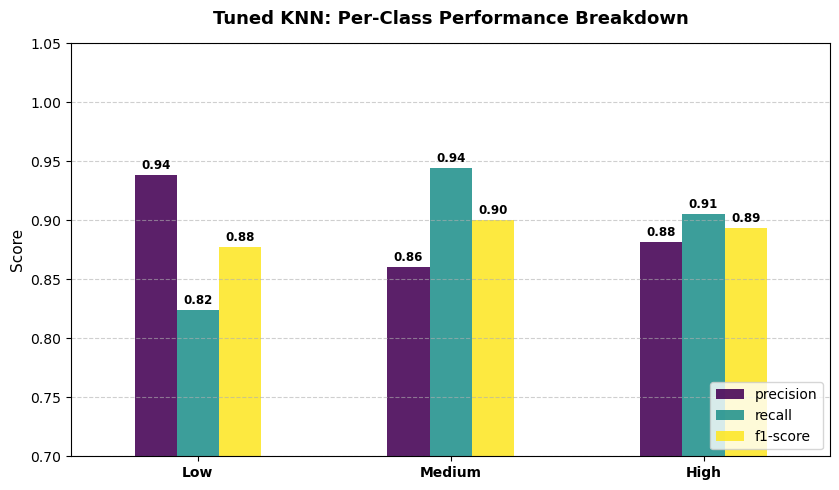

In [26]:
import os
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import classification_report

# 1. Ensure directory and class names exist
os.makedirs('../results/eda_visualizations', exist_ok=True)
class_names = ['Low', 'Medium', 'High']

# 2. Generate classification report dictionary
report = classification_report(
    y_test, 
    tuned_knn_preds, 
    target_names=class_names, 
    output_dict=True
)

# 3. Extract precision, recall, and f1-score for classes 0, 1, 2
df_metrics = pd.DataFrame(report).transpose().iloc[:3, :3]

# 4. Plot grouped bar chart
ax = df_metrics.plot(
    kind='bar', 
    figsize=(8.5, 5), 
    colormap='viridis', 
    edgecolor='none', 
    alpha=0.88
)

plt.title('Tuned KNN: Per-Class Performance Breakdown', fontsize=13, fontweight='bold', pad=14)
plt.ylabel('Score', fontsize=11)
plt.ylim(0.70, 1.05)
plt.xticks(rotation=0, fontsize=10, fontweight='semibold')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend(loc='lower right', frameon=True, facecolor='white')

# 5. Add value labels on top of each bar
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f"{height:.2f}",
            (p.get_x() + p.get_width() / 2., height),
            ha='center', 
            va='bottom', 
            fontsize=8.5, 
            fontweight='bold',
            xytext=(0, 2),
            textcoords='offset points'
        )

plt.tight_layout()
plt.savefig('../results/eda_visualizations/knn_per_class_metrics.png', dpi=200)
plt.show()